<div class="alert alert-block alert-info">
¡Hola! David ¿cómo vas?

Mi nombre es Santiago. Un gusto conocerte, seré tu revisor en este proyecto.

Cuando encuentre un error por primera vez, simplemente lo señalaré para que lo detectes y corrijas por tu cuenta. Si en la siguiente iteración no lograste resolverlo, te daré una pista más precisa con ejemplos. ¡También estoy disponible para cualquier duda que tengas!

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>

Éxito. Todo se ha hecho de forma correcta.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>

Observación. Algunas recomendaciones o mejoras menores.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>

Necesita arreglos. El trabajo no puede ser aceptado con comentarios rojos.
</div>

<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:

Respuesta del estudiante.
</div>

<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

Antes de entrar en el detalle, quiero compartirte mis impresiones generales.

Este proyecto tiene muy buena base: el diagnóstico de sentinels es correcto, la detección del 2026 y el diagnóstico de fechas son perfectos, la corrección con `.loc[year == 2026] = pd.NaT` es exacta, el MAR está correctamente identificado (incluyendo la observación del length de 1490 caracteres), `how="left"` en el merge, `np.select` con umbrales exactos, y el insight ejecutivo es completo con segmentos bien descritos, análisis de outliers y 3 recomendaciones diferenciadas. ¡Buen trabajo!

Hay dos puntos que necesitan corrección antes de aprobar:

- **Diagnóstico de nulos (celda 16):** para `churn_date` propone "eliminar la columna" — los nulos significan que el cliente sigue activo, no que el dato esté malo. Para `city` dice "mantener tal cual" sin mencionar la acción sobre el sentinel `"?"`.
- **GitHub:** placeholder sin reemplazar y link en celda de código sin ejecutar.

¡Estás muy cerca!

Saludos.
</div>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [62]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [64]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [65]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [66]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [67]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [68]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [69]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [70]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien verificando dimensiones con `.shape` e inspeccionando los tres datasets con `.info()`. ✅
</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [71]:
# cantidad de nulos para users
print((users).isna().sum()) # Cantidad de valores nulos}
print()
print(users.isna().mean().map('{:.2%}'.format)) # Proporción de valores nulos


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.00%
first_name     0.00%
last_name      0.00%
age            0.00%
city          11.72%
reg_date       0.00%
plan           0.00%
churn_date    88.35%
dtype: object


In [72]:
# cantidad de nulos para usage

print((usage).isna().sum())
print()
print(usage.isna().mean().map('{:.2%}'.format)) 


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id           0.00%
user_id      0.00%
type         0.00%
date         0.12%
duration    55.19%
length      44.74%
dtype: object


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien calculando nulos con `isna().sum()` e `isna().mean()`. ✅
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

 ---


**DATAFRAME USERS**


1. El DF Users tiene valores faltantes en las columnas city con un porcentaje del 11,72% y churn_date con un valor de 88,35%. 



2. Para el analisis, la columna city se mantendran los datos tal cual debido a que es una columna de texto, sin embargo, dentro del analisis previo hay 96 registros con "?" los cuales deben ser reemplazados por valores nulos debido a que son ciudades que en su momento no fueron registrados correctamente o hubo fallas en su registro por parte de los usuarios.

Para la columna churn_date, se encuentran muchos datos en blanco los cuales se interpretan como datos nulos pero realmente no es un problema con los datos. Esto significa que hay clientes que todavia siguen activos(88,35%), respectivamente y solo hay 11,65% de clientes inactivos los cuales estan registrados y tienen fecha de fin de contrato con el operador. Debido a que esta información es util, se conservara para los analisis que hayan que realizar mas adelante en este proyecto. 



**DATAFRAME USAGE**

1. El DF Usage tiene valores faltantes en las columnas duration con un porcentaje del 55,19% y length con un valor de 44,74%. La columna date tambien tiene datos faltantes con proporción del 0,12%.

2. Para el analisis, debemos estudiar con detenimiento cada una de estas columnas y analizar el impacto que se realize al reemplazar los valores de estas columnas. Para el caso particular de la columna Date, debemos analizar la información que contiene esta columna y tomar la decisión correcta. 

  

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Buen diagnóstico con cifras exactas! El análisis de `duration` y `length` es correcto. ✅

Dos ajustes:

**1. `churn_date` — "eliminar la columna":** El 88.35% de nulos no es un problema de datos — significa que esos clientes **siguen activos** y aún no tienen fecha de cancelación. Eliminar la columna haría perder esa información de negocio valiosa. La acción correcta es conservarla e interpretarla como condición de estado del cliente.

**2. `city` — "mantener los datos tal cual":** Correcto para los 469 nulos genuinos ✅, pero hay una acción adicional: los 96 registros con el valor `"?"` (sentinel) deben reemplazarse explícitamente por `pd.NA`. Tu código en la celda 39 ya lo hace — solo falta mencionarlo en el diagnóstico.
</div>

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [73]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` tiene un registro total de 4000 datos, en esta columna se evidencia que hay 4000 usuarios diferentes, con nombres repetidos pero de diversas ciudades y edades.

- La columna `age` tiene 4000 registros de los cuales se halla un valor anormal que es "-999" el cual se debe analizar a fondo cuantos datos tiene para poder realizar el procedimiento respectivo, ya que este valor distorsiona los demas registros, en especial la desviación estandar. 


In [74]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Las columnas `id` y `user_id` tienen un total de 40000 registros de los cuales, la columna ID representa el registro de la actividad realizada (llamada o mensaje de texto) y user_id la persona que realizo la actividad. Por lo tanto, la columna ID no representa un valor real para el analisis.


- Las columnas `duration` y `lenght` tienen un total de 17924 y 22104 registros respectivamente. En la columna `duration` se ve una llamada con registro de 120 minutos el cual se debe analizar e identificar cuantos registros se tienen de ello. En la columna `lenght` se ve un mensaje de texto con 1490 caracteres los cuales exceden el limite de 160 caracteres, tambien se debe analizar cuantos registros hay con ese dato. 

In [75]:
# explorar columnas categóricas de users
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [76]:
users['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` tiene un registro de 6 ciudades, pero hay una ciudad que aparece con "?", en este campo se hallan 96 datos los cuales representan el 2,4% de los registros. La columna city tiene 11,72% de valores nulos. Asumiendo que cuando hay registros que tienen este dato "?", deben ser reemplazados por nulos, al hacer este reemplazo, el porcentaje cambiaria a 14,125% el cual lo confirmaremos mas adelante. 

- La columna `plan` solo tiene 2 registros de 2 planes que son Basico y Premium. No se halla ningun valor sospechoso. 

In [77]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` representa el tipo de actividad que realizo un usuario determinado, en este caso si fue una llamada (call) o mensaje de texto(text). En el DF se evidencia que los mensajes de texto fue la actividad que mas se frecuento. 


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Bien confirmando que `type` solo tiene `call` y `text`! ✅
</div>

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**RESPUESTAS**

1. En la columna city se hallo un valor "?" el cual se asume como dato nulo y de acuerdo a los tips recomendados, se transforma el dato en nulo debido a que esta columna es de texto y no numerica, por lo que no pueden hacer operaciones matematicas.
   
3. En la columna Age, se reportan edades de "-999" y para este tipo de datos nulos, se reemplazaran estos datos con la mediana, de acuerdo a las recomendaciones de este contenido. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Diagnóstico de sentinels correcto! `"?"` en city → transformar a nulo ✅ y `-999` en age → reemplazar con la mediana ✅.
</div>

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [78]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce") # completa el código

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡`errors="coerce"` en ambas conversiones a datetime! ✅
</div>

In [79]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")# completa el código

In [80]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se ve que el año 2026 tiene un registro de 40 datos los cuales se pueden concluir como error de captura de datos, ya que en esa fecha 2026, aparece el mes y el dia exacto en el Dataframe Users.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Bien detectando los 40 del 2026 e identificando que comparten la misma fecha exacta (2026-05-10) — señal de error de captura! ✅
</div>

In [81]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, solo tenemos el año 2024 como fecha, esta solo cuenta con 50 registros faltantes o vacios que se asumen como Null en el Dataframe Usage. 

Basaremos el análisis en estas fechas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien confirmando que `date` solo tiene 2024 y los 50 nulos. ✅
</div>

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? RTA: Si, en el DF Users, aparece el año 2026 con fecha exacta 2206-05-10 el cual es una fecha que no ha transcurrido. 
- ¿Qué harías con ellas? Transformar esos datos como nulos, ya que cada registro es un contexto diferente y poner otra fecha cualquiera no tiene sentido. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Diagnóstico de fechas correcto! Identificas el 2026 como fecha imposible y propones transformarlos a nulos conservando el resto del registro. ✅
</div>

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [82]:
# Analizar columna Age antes de transformar.
users['age'].describe().round(1)

count    4000.0
mean       33.7
std       123.2
min      -999.0
25%        32.0
50%        47.0
75%        63.0
max        79.0
Name: age, dtype: float64

In [83]:
# Reemplazar -999 por la mediana de age

# Paso 1: convertir el sentinel -999 en NaN
users["age"] = users["age"].replace(-999, np.nan)

# Paso 2: calcular la mediana (ya sin el -999 distorsionando el cálculo)
age_mediana = users["age"].median()

# Paso 3: reemplazar los NaN con la mediana
users['age'] = users["age"].fillna(age_mediana)

# Verificar cambios
users['age'].describe().round(2)

count    4000.00
mean       48.14
std        17.69
min        18.00
25%        33.00
50%        48.00
75%        63.00
max        79.00
Name: age, dtype: float64

In [84]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace(["?", "NA"], pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [85]:
#Validar el DF despues del cambio ajustado para el campo City.
print((users).isna().sum())

user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [86]:
# Marcar fechas futuras como NA para reg_date
fecha_futura = users['reg_date'].dt.year == 2026
users.loc[fecha_futura, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Mediana de `age` excluyendo el sentinel ✅, `pd.NA` en city ✅, y `.loc[year == 2026] = pd.NaT` con verificación de cambios ✅ — todo correctamente implementado!
</div>

In [87]:
#Validar el DF despues del cambio ajustado para el campo reg_date
print((users).isna().sum())

user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date        40
plan             0
churn_date    3534
dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [88]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [89]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**DIAGNOSTICO**

En el campo "duration" tiene campos vacios debido a que en su selección, aparecen registros de mensajes de texto, es decir, en los mensajes de texto, la duración de llamadas queda en blanco por logica razón, se enviaron mensajes de texto pero no llamadas. 

En el campo "length" tiene campos vacios debido a que en su selección, se realizaron llamadas directamente sin realizar mensajes de texto, es por eso que esos campos estan vacios.

Los anteriores campos son MAR que son valores faltantes que dependen de otras variables observadas, pero no del valor faltante directamente.

DATO CLAVE: Se encuentra un valor en length de 1490 caracteres, se sabe que el limite de los mensajes de texto es de 160, este dato representa un dato outlier. Es posible que estos datos hayan sido causados por error en el procesamiento de los datos


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡MAR correctamente identificado y muy bien justificado! La observación sobre el valor de 1490 caracteres en `length` (cuando el máximo de un SMS es 160) demuestra un nivel de análisis exploratorio muy cuidadoso. ✅
</div>

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [90]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text':'sum',
    'is_call':'sum',
    'duration': 'sum'
}).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [91]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes'})
usage_agg = usage_agg.rename(columns={'is_call': 'cant_llamadas'})
usage_agg = usage_agg.rename(columns={'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [92]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Agrupación y merge con `how="left"`! ✅

Tip: las celdas 54-59 muestran el `describe()` columna por columna de forma separada. Para una vista más limpia y consolidada de las 4 columnas relevantes:

```python
user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()
```
</div>

In [93]:
user_profile.to_csv('user_profile.csv', index=False)

In [94]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               4000 non-null   int64         
 1   first_name            4000 non-null   object        
 2   last_name             4000 non-null   object        
 3   age                   4000 non-null   float64       
 4   city                  3435 non-null   object        
 5   reg_date              3960 non-null   datetime64[ns]
 6   plan                  4000 non-null   object        
 7   churn_date            466 non-null    object        
 8   cant_mensajes         3999 non-null   float64       
 9   cant_llamadas         3999 non-null   float64       
 10  cant_minutos_llamada  3999 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 375.0+ KB


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [95]:
# Resumen estadístico de las columnas numéricas
user_profile['age'].describe().round(2)

count    4000.00
mean       48.14
std        17.69
min        18.00
25%        33.00
50%        48.00
75%        63.00
max        79.00
Name: age, dtype: float64

In [96]:
user_profile['age'].median()

48.0

In [97]:
user_profile['cant_mensajes'].describe().round(2)

count    3999.00
mean        5.52
std         2.36
min         0.00
25%         4.00
50%         5.00
75%         7.00
max        17.00
Name: cant_mensajes, dtype: float64

In [98]:
user_profile['cant_mensajes'].mode()

0    5.0
dtype: float64

In [99]:
user_profile['cant_llamadas'].describe().round(2)

count    3999.00
mean        4.48
std         2.14
min         0.00
25%         3.00
50%         4.00
75%         6.00
max        15.00
Name: cant_llamadas, dtype: float64

In [100]:
user_profile['cant_minutos_llamada'].describe().round(2)

count    3999.00
mean       23.32
std        18.17
min         0.00
25%        11.12
50%        19.78
75%        31.42
max       155.69
Name: cant_minutos_llamada, dtype: float64

In [101]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True) * 100).map('{:.2f}%'.format)

Basico     64.88%
Premium    35.12%
Name: plan, dtype: object

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

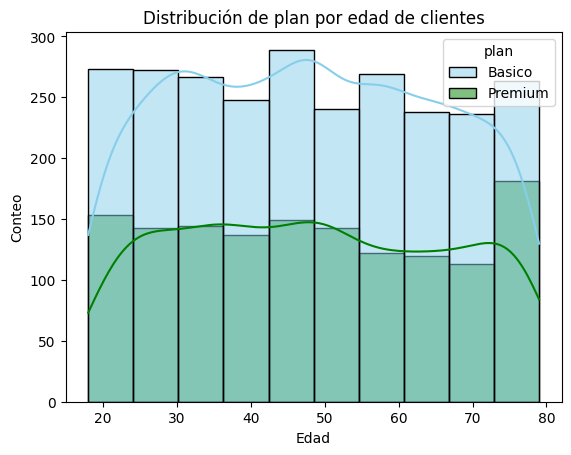

In [102]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title("Distribución de plan por edad de clientes")
plt.xlabel( "Edad")
plt.ylabel("Conteo")
plt.show()

💡Insights: En el histograma se encuentran varios fenomenos:

1. Los usuarios contratan mas planes de datos Basicos que Premium. Este fenomeno se puede dar por el poder adquisitivo de los usuarios que deciden comprar planes mas economicos y que esten al alcance de su bolsillo. 
2. Los usuarios de tercera edad, en especial en el rango de 70-80 años son los que mas compran plan de datos Premium, a comparación del otro tipo de plan de datos donde hay muy bajos registros de compra por parte de este grupo. Este fenomeno se puede dar por promociones que la empresa haya hecho para ese tipo de personas.
3. El plan de datos premium llega a su pico alto en el rango de personas aproximadamente 44-55 años y de ahi registra un comportamiento con tendencia a la baja. El plan de datos Basico llega a su pico alto sobre el rango de los 42-52 años y tambien empieza a registrar un proceso a la baja.
4. Los jovenes compran mas plan de datos Premium que planes de datos basico. Puede deberse a que este grupo de personas cuenta con un mejor poder adquisitivo sobre ello

- Distribución: Su distribución no tiene una caracteristica general, es mas especifica por cada plan de datos. En plan Premium presenta una distribución bimodal debido a que hay 2 picos en ciertos rangos de edades, mientras que en plan Basico, los datos se encuentran mas concentrados en las edades de 42-48 años aproximadamente, desde este rango, empieza una tendencia a la baja en la compra de plan de datos por parte de las personas que son mayores de 49 años, por lo que el sesgo esta distribuido hacia la derecha pero de una manera leve. 

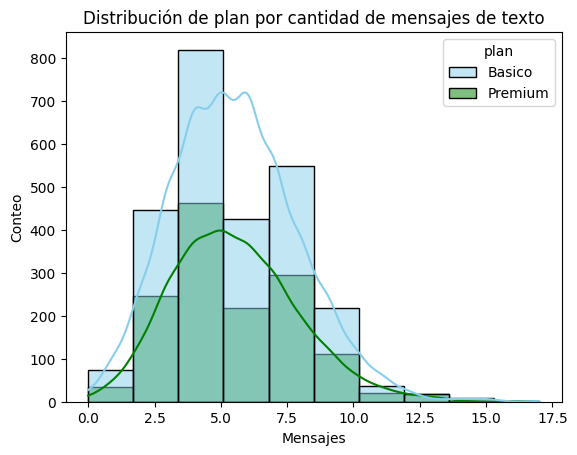

In [103]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title("Distribución de plan por cantidad de mensajes de texto")
plt.xlabel( "Mensajes")
plt.ylabel("Conteo")
plt.show()



💡Insights: Aca tambien hay varios fenomenos: 


1. En los planes de datos premium y basico, en cada categoria se evidencia un comportamiento casi parecido, evidenciando la misma cantidad aproximada de envio de mensajes de texto en planes Premium y Basico.
2. Se evidencia que el pico mas alto se registra en los planes de datos que envian 3,5 a 5 mensajes de texto con registros superiores a los 800 conteos (combinando ambos planes), teniendo un conteo alto en ambos planes de datos por separado.
3. Se evidencia un leve aumento en la mensajeria de texto despues de los 7 mensajes de texto enviados con registros de 300 conteos aproximadamente y vielve a la baja. 


- Distribución: Se evidencia una distribución sesgada a la derecha en los dos planes pero: En el plan premium, la tendencia comienza a bajar despues de los 5.0 mensajes enviados formando una cola larga hacia la derecha y en plan basico, despues de los 6.0 mensajes, tambien presenta el mismo comportamiento de la cola larga. Se concluye un comportamiento un poco parecido a nivel de envio de mensajes, donde los usuarios envian mensajes de texto en planes de datos basicos y premium, con una pequeña diferencia de apenas 1 mensaje de texto en plan basico que premium. 



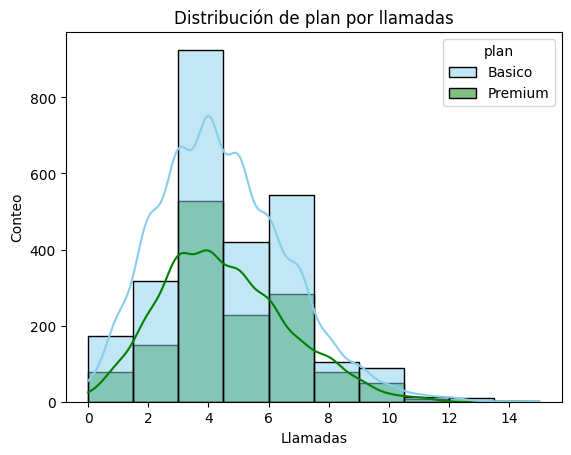

In [104]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title("Distribución de plan por llamadas")
plt.xlabel( "Llamadas")
plt.ylabel("Conteo")
plt.show()

💡Insights: En este histograma se evidencian los siguientes comportamientos:


1. En los planes de datos premium y basico, en cada categoria se evidencia un comportamiento casi parecido, evidenciando la misma cantidad aproximada de llamadasen planes Premium y Basico.
2. Se evidencia que el pico mas alto se registra en los planes de datos que realizan llamadas de aproximadamente 4,4 con registros superiores a los 900 conteos (combinando ambos planes), teniendo un conteo alto en ambos planes de datos por separado.
3. Se evidencia un leve aumento en las llamadas despues de los 6 llamadas con conteos cercanos a las 600 registros (combinando ambos planes) despues de que el registro de llamadas alto sobre 4,4 (pico mas alto), empieza a bajar y despues empieza a tener un decrecimiento(cola larga).

- Distribución: Se evidencia una distribución sesgada a la derecha en los dos planes, siendo el plan de datos basico el de mayor comportamiento o registro alto de llamadas. 

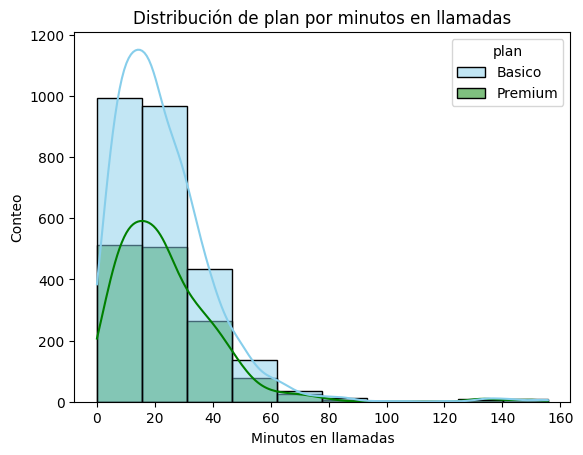

In [105]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title("Distribución de plan por minutos en llamadas")
plt.xlabel( "Minutos en llamadas")
plt.ylabel("Conteo")
plt.show()

💡Insights: Analizemos este diagrama:

1. El pico alto de duración de llamadas en plan de datos Premium es cercano a los 15 min con registros de 550 llamadas aproximadamente y en plan Basico de 460 llamadas aproximadamente con el mismo tiempo de duración.
2. Las llamadas reportadas despues de los 30 minutos empieza a presentar una caida baja de manera drastica. A medida que aumenta la duración de llamadas, el conteo se reduce de manera destica. 

Distribución: Se evidencia un sesgo a la derecha debido a que los datos estan mas ubicados a la izquierda y la cola larga se encuentra en la parte derecha. En el anterior comentario, se mencionaba que a medida que las llamadas aumentaban en minutos hasta los 30 minutos, el numero de registros es alto y despues de ese registro, el numero empieza a bajar. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Los cuatro histogramas tienen `hue="plan"`, títulos, etiquetas e insights descriptivos con fenómenos observados por variable! ✅
</div>

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

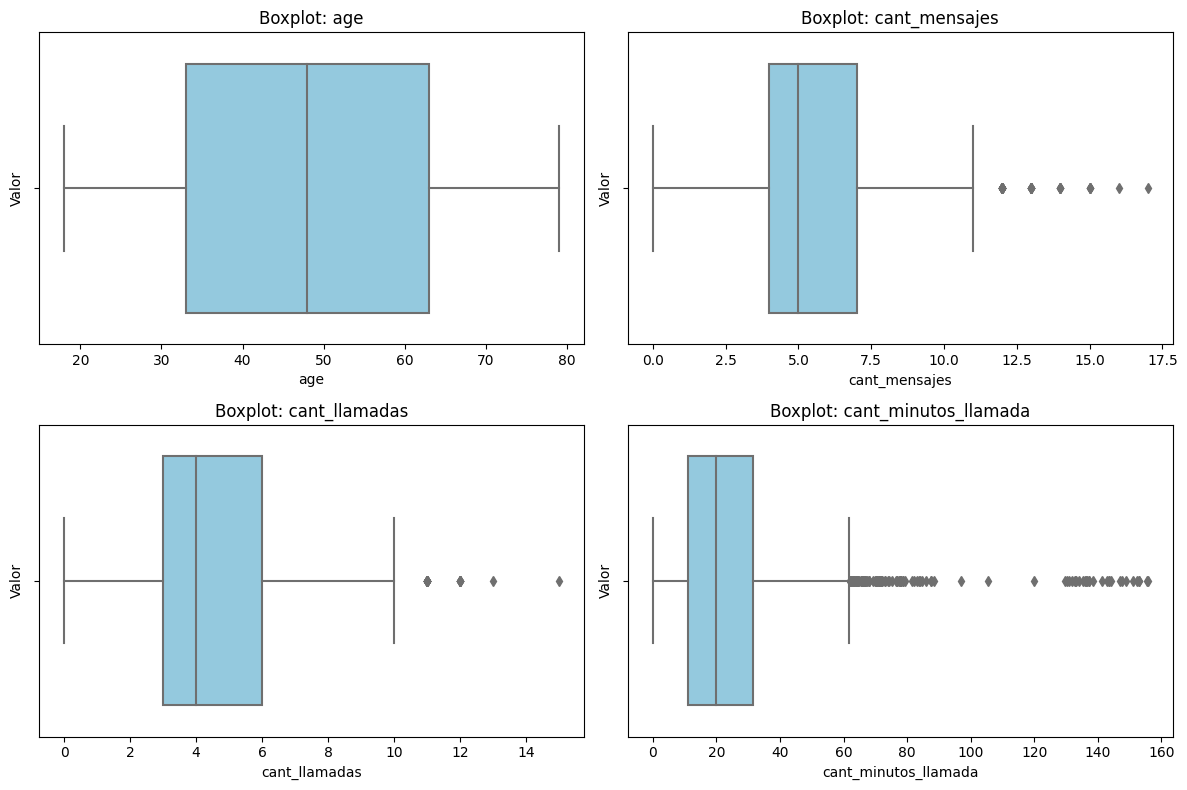

In [106]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(12, 8))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel('Valor')
    
plt.tight_layout()  # Ajusta los espacios entre gráficos
plt.show()

💡Insights: 

- Age: El boxplot age no presenta ningun tipo de outliers, ya que despues de los limites inferior y superior, no se evidencian datos atipicos. El grafico clasifica solo el grupo de personas que han adquirido un plan de datos, teniendo como limite inferior, las personas de 18 años y el limite superior las personas de 79 años. Estos datos corresponden al min y max descritos en la celdas anteriores. El rango intercuartil se concentra en las personas de 33 a 63 años donde se clasifican como las personas que mas hicieron compra de plan de datos(Basico o Premium). No hay valores atipicos debido a que para comprar cualquier plan, cualquier persona debe ser mayor de edad (+18 años) y no hay registros de personas con mas de 80 años que hayan comprado algun plan de datos.

- cant_mensajes: El boxplot cant_mensajes presenta un outlier a la derecha. Comparando este grafico con el .describe() de esta columna, encontramos que se ven muy pocos puntos estirados a la derecha de acuerdo al grafico. Cada uno de nuestros clientes que cuentan con algun plan de datos, han enviado de 4 a 7 mensajes de texto durante su contrato. Al analizar el IQR, se ve que la mediana no se encuentra de manera centralizada, sino mas tirada hacia el costado izquierdo. Su limite inferior calculado es -0.5 y su limite superior llega hasta 11.5 sin contar datos atipicos. Si tomamos el limite superior y se compara con el valor maximo, confirmamos que hay outliers o valores atipicos. Estos pueden surgir por clientes que han enviado una cantidad alta de mensajes de texto o simplemente por errores de captura. 
  
- cant_llamadas: El boxplot cant_llamadas presenta un outlier a la derecha. Analizando este mismo grafico con el .describe() de esta columna y viendo un comportamiento similar en el boxplot de los mensajes, tambien vemos muy pocos puntos estirados a la derecha de acuerdo al grafico. Nuestros clientes que cuentan con plan de datos, han realizado 3 a 6 llamadas en su contrato. Analizando el IQR, se ve que la mediana esta mas tirada a la izquierda que al centro. Su limite inferior es de -1,5 y su limite superior es de 10.5 sin contar con datos atipicos. Tomando el limite superior comparado con el valor maximo, aqui se evidencian valores atipicos o outliers como se explico al comienzo. Esta tendencia puede deberse a que hubieron clientes que hicieron un mayor numero de llamadas por fuera del limite superior.

- 
- cant_minutos_llamada: El boxplot cant_minutos_llamadas presenta un outlier muy alto a la derecha. Los datos estan mas concentrados hacia la parte izquierda. Tomando el .describe() de esta columna, a diferencia de los 2 anteriores boxplot, aqui si vemos bastantes valores atipicos dispersos en la parte derecha. Aqui encontramos clientes que en su plan de datos han realizado llamadas de 11.12 a 31.42 minutos, con base al boxplot comparado con las cifras del .describe() que representan el Q1 y Q3. La mediana que es 19.78 esta mas cerca del valor del Q1 que del Q3, es decir, con tendencia al costado izquierdo. Los valores en cuanto a limite inferior es de -19,32 y limite superior de 61,85. Comparanto este ultimo valor con el maximo que es de 155,69, se confirma lo mencionado anteriormente. La tendencia puede darse a que hayan clientes que hicieron llamadas con duración de 150 minutos aproximadamente, que son casos que se pueden dar aunque es poco probable en el mundo de hoy. 
- 

In [107]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    print(f"{col}: Q1={q1}, Q3={q3}, IQR={iqr}, límite inferior={limite_inf}, límite superior={limite_sup}\n")

cant_mensajes: Q1=4.0, Q3=7.0, IQR=3.0, límite inferior=-0.5, límite superior=11.5

cant_llamadas: Q1=3.0, Q3=6.0, IQR=3.0, límite inferior=-1.5, límite superior=10.5

cant_minutos_llamada: Q1=11.12, Q3=31.415, IQR=20.295, límite inferior=-19.322500000000005, límite superior=61.8575



In [108]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.00,3999.00,3999.00
mean,5.52,4.48,23.32
std,2.36,2.14,18.17
min,0.00,0.00,0.00
25%,4.00,3.00,11.12
50%,5.00,4.00,19.78
75%,7.00,6.00,31.42
max,17.00,15.00,155.69


💡Insights: 
- cant_mensajes: Mantener los outliers debido a que los puntos atipicos estan cerca del limite superior que es 11,5 y no se evidencia un alejamiento extremo, apenas su diferencia es de 5,5 mensajes (diferencia muy pequeña) con respecto al valor maximo de 17. Se mantiene debido a que pueden haber clientes que en su contrato de plan de datos hayan enviado mas de 11 mensajes de texto (registro maximo de 17) durante su periodo de contrato. En el DF, solo se hallaron 46 registros de mas de 11 mensajes, representando el 1.15% del dataframe, una proporción muy baja.

- cant_llamadas: Mantener los outliers debido a que los puntos atipicos estan cerca del limite superior que es 10,5 y no se evidencia un alejamiento extremo, apenas su diferencia es de 4,5 llamadas (diferencia muy pequeña) con respecto al valor maximo de 15. Se mantiene debido a que pueden haber clientes que en su contrato de plan de datos hayan realizado mas de 10,5 llamadas. En el DF, solo se hallaron 30 registros con mas de 10 llamadas, representando el 0,75% del dataframe, una proporción muy baja(ver codigo en la siguiente celda).

- cant_minutos_llamada: Mantener los outliers debido a que los puntos atipicos estan cerca del limite superior que es 61,8575 pero se evidencia un nivel de outliers alto con base al valor maximo que es 155,69 minutos. Realizando el filtrado de datos del DF, este comportamiento representa 109 registros con esos outliers altos, apenas el 2,725% del DF. Se mantienen los datos debido a que el DF no da una información mas de fondo del porque de este comportamiento y pueden haber casos donde los clientes realizen llamadas de mas de 1 hora debido a que pueden ser clientes que tienen planes ilimitados, puede ser un cliente corporativo, entre otros factores. Estos casos deben ser investigados mas a fondo para estos clientes y evidenciar su comportamiento en tiempo real, lo anterior es una hipotesis de un comportamiento que se puede dar pero es clave este proceso para una correcta toma de decisiones. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡IQR con comparación límite vs máximo e insights que justifican mantener los outliers como clientes de alto consumo! ✅

Tip: calcula también el **límite inferior** para el análisis completo:

```python
limite_inferior = Q1 - 1.5 * IQR
```
</div>

In [109]:
total_registros = (user_profile['cant_llamadas'] > 10).sum()
print(total_registros)

30


In [110]:
total_registros2 = (user_profile['cant_minutos_llamada'] > 61.8575).sum()
print(total_registros2)

109


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [111]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = ''


condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
]

resultados = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, resultados, default='Alto Uso')


In [112]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto Uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto Uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [113]:
user_profile.to_csv('user_profile.csv', index=False)

In [114]:
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto Uso      279
Name: grupo_uso, dtype: int64

In [115]:
(user_profile['grupo_uso'].value_counts(normalize=True) * 100).map('{:.2f}%'.format)

Uso medio    73.58%
Bajo uso     19.45%
Alto Uso      6.98%
Name: grupo_uso, dtype: object

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [116]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = ''

condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60),
]

resultados = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, resultados, default='Adulto Mayor')


In [117]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [118]:
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [119]:
(user_profile['grupo_edad'].value_counts(normalize=True) * 100).map('{:.2f}%'.format)

Adulto          50.45%
Adulto Mayor    30.55%
Joven           19.00%
Name: grupo_edad, dtype: object

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

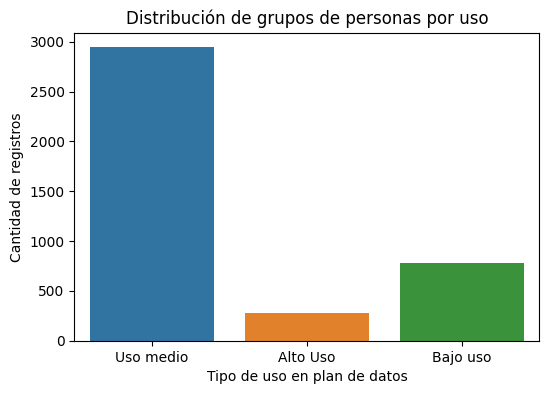

In [120]:
# Visualización de los segmentos por uso


plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de grupos de personas por uso')
plt.xlabel('Tipo de uso en plan de datos')
plt.ylabel('Cantidad de registros')
plt.show()



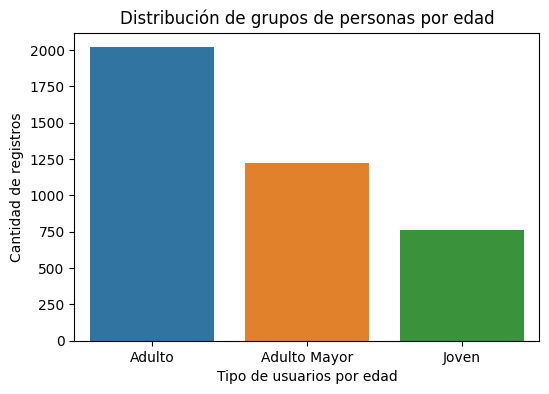

In [121]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de grupos de personas por edad')
plt.xlabel('Tipo de usuarios por edad')
plt.ylabel('Cantidad de registros')
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡`np.select` con umbrales exactos y capitalización correcta! ✅

Tip: agrega `order=["Bajo uso","Uso medio","Alto uso"]` y `order=["Joven","Adulto","Adulto Mayor"]` en los countplots para garantizar el orden lógico de las barras independientemente del conteo.
</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

En el DF users, se encontraron 2 columnas como City y Churn date que tenían datos nulos (11,72% y 88,35% respectivamente). En el DF usages se encontraron valores nulos en las columnas Duration y Length con valores de 55,19% y 44,74% respectivamente. 

En la columna length del DF Usages se hallaron registros de mensajes de texto de 1490 caracteres cuando el máximo debía de haber sido de 160 caracteres, en el DF se hallaron un total de 30 registros. En la columna city del DF Users se encontraron ciudades con registro “?” el cual se encontraron un total de 96 registros. 


🔍 **Segmentos por Edad**

En grupo edad, se ve que los adultos son los usuarios con mas registros en la compra de plan de datos sea premium o básico, seguido del adulto mayor con una cifra un poco mayor a la mitad de los usuarios adultos. Los jóvenes cuentan con un registro muy bajo, con cerca de 750 registros. 

📊 **Segmentos por Nivel de Uso**

En Connectatel, hay una tendencia en la cual hay usuarios que compran mas plan de datos básico que premium por temas económicos, a pesar de que el premium ofrece más beneficios, pero a un mayor costo. 
De acuerdo con las gráficas anteriores, se evidencia un uso medio por parte de las personas en el plan de datos, sospechando que en su actividad se realizan llamadas y mensajes de texto. Muy pocos registros con uso alto y bajo, aunque este ultimo con mas registros que alto pero muy por debajo del uso medio. 

**Segmentos claves para ConnectaTel**

El segmento de uso alto representa apenas el 6,98% de los usuarios, los cuales son usuarios que mayor consumen navegación a internet (pueden ser jovenes) y son los que mayor probabilidad de fidelización tienen, es decir, son clientes que se pueden retener a largo plazo. Estos son clientes con pocas probabilidades de que cancelen el contrato.

El segmento de uso bajo con el 19,45% representa una oportunidad para la empresa, se debe realizar una investigación mas exhaustiva sobre su comportamiento y analizar que campañas se pueden hacer para que a largo plazo sean clientes con al menos consumo intermedio.

El segmento de clientes de uso medio con 73,58% son los clientes que mas le dan ingresos a la empresa. Es posible que estos clientes se caracterizan por comprar planes de datos más económicos sin tener que estar ligado a un contrato de plan de datos permanente. Estos clientes posiblemente compran mas estos planes debido a que esta mas asequible a su bolsillo y no les interesa comprar plan premium a largo plazo.  

**Outliers detectados**

Se detectaron outliers en las columnas de "cant_mensajes", "cant_llamadas" y "cant_minutos_llamada", este ultimo en especial, tuvo un numero de Outliers alto, mientras que los otros tuvieron un registro aun mas bajo. Para la columna cant_minutos_llamadas, se encontraron clientes que realizaron llamadas con registro superior a los 60 minutos, el cual podrian ser clientes VIP que tienen plan de datos Premium el cual cuenta con varios beneficios.


💡 **Recomendaciones**

1. Potenciar un poco mas el plan de datos Basico el cual es el plan mas comprado por los clientes, si bien para estos clientes esta al alcance del bolsillo, hay que ofrecer mas promociones para retener a estos clientes. Esta potenciación debe estar mas orientada a las personas adultas que no quieren contratar plan de datos Premium por costos, sino que quieren tener plan basico para sus necesidades diarias.
2. Identificar el comportamiento de las personas clasificadas como adultos mayores e identificar el plan que mas compran para brindar nuevas promociones y beneficios a esta población para fidelizarlos.
3. Identificar porque hay pocos jovenes con respecto a los otros grupos los cuales tienen contrato con este operador e identificar si es que este grupo compra planes con otro operador diferente y realizar promociones a este grupo para atraer mas clientes jovenes y lograr una mayor retención de clientes. 


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Insight ejecutivo muy completo! Tiene todos los problemas detectados con cifras, segmentos por edad y uso con porcentajes concretos, análisis de outliers con contexto de negocio (clientes VIP Premium), y 3 recomendaciones diferenciadas por segmento de edad. ✅
</div>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/Dgavilanp/Proyecto-Final-Sprint-7`